# 🔬 Fraud Detection — SHAP Explainability
**Why SHAP?** XGBoost is a black box. SHAP (SHapley Additive exPlanations) makes it interpretable.
Based on game theory — each feature gets credit for how much it contributed to the prediction.
This is what separates a good ML project from a great one on a resume.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import shap
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

plt.style.use('dark_background')
shap.initjs()  # Initialize JS for notebook plots

# ✅ Auto-detect: Google Colab vs Local
if os.path.exists('/content/creditcard.csv'):
    DATA_PATH = '/content/creditcard.csv'
    REPORTS_DIR = '/content/reports'
    MODELS_DIR = '/content'
else:
    DATA_PATH = '../data/creditcard.csv'
    REPORTS_DIR = '../reports'
    MODELS_DIR = '../content'

os.makedirs(REPORTS_DIR, exist_ok=True)
print(f'Data path   : {DATA_PATH}')
print(f'Reports dir : {REPORTS_DIR}')
print(f'Models dir  : {MODELS_DIR}')
print('SHAP version:', shap.__version__)

Data path   : /content/creditcard.csv
Reports dir : /content/reports
Models dir  : /content
SHAP version: 0.52.0


## 1. Load Model & Data

In [5]:
# Load saved model
xgb = joblib.load(f'{MODELS_DIR}/xgb_model.pkl')
print('Model loaded.')

# Reproduce same test set
df = pd.read_csv(DATA_PATH)
scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled'] = scaler.fit_transform(df[['Time']])

feature_cols = [f'V{i}' for i in range(1, 29)] + ['Amount_scaled', 'Time_scaled']
X = df[feature_cols]
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Use a sample for SHAP (full test set is slow)
sample_size = 2000
X_sample = X_test.sample(n=sample_size, random_state=42)
print(f'Using {sample_size} samples for SHAP analysis')

Model loaded.
Using 2000 samples for SHAP analysis


## 2. Compute SHAP Values

In [6]:
# TreeExplainer is optimized for tree-based models (XGBoost, LightGBM, etc.)
print('Computing SHAP values... (takes ~30 seconds)')
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_sample)

print(f'SHAP values shape: {shap_values.shape}')
print(f'Expected value (base rate): {explainer.expected_value:.4f}')

# For XGBoost binary classification, shap_values is 2D
# Each row = one transaction, each column = one feature's contribution

Computing SHAP values... (takes ~30 seconds)
SHAP values shape: (2000, 30)
Expected value (base rate): -0.0308


## 3. Global Explainability — Feature Importance

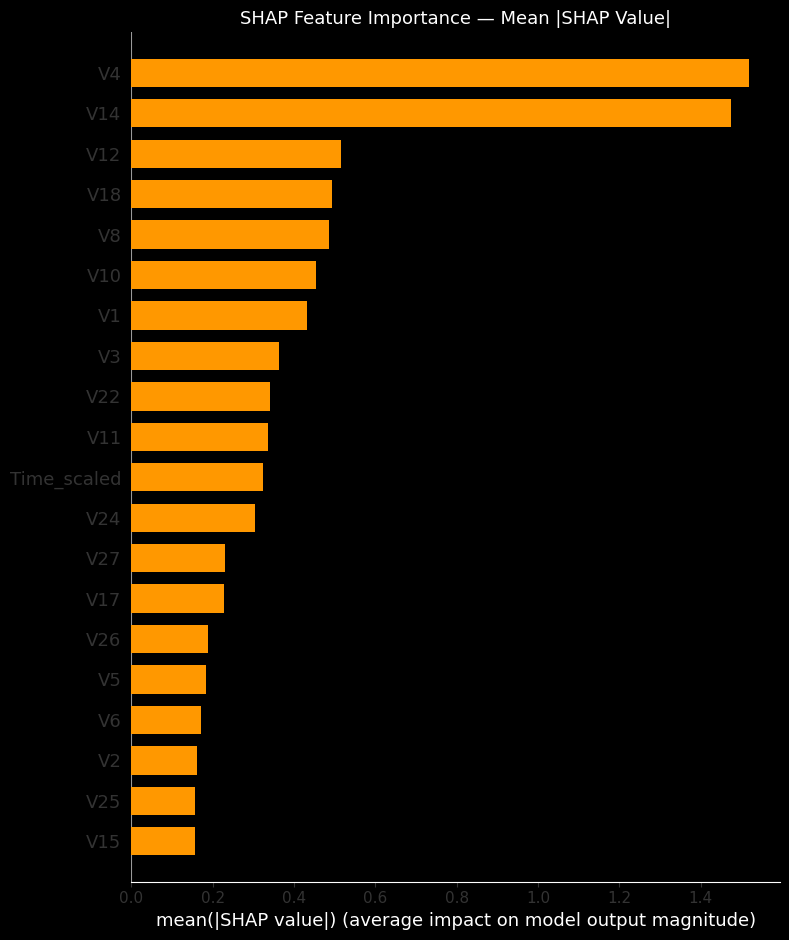

In [7]:
# Summary plot — shows overall feature importance + direction
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_sample,
    plot_type='bar',
    show=False,
    color='#FF9800'
)
plt.title('SHAP Feature Importance — Mean |SHAP Value|', fontsize=13)
plt.tight_layout()
plt.savefig(f'{REPORTS_DIR}/shap_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

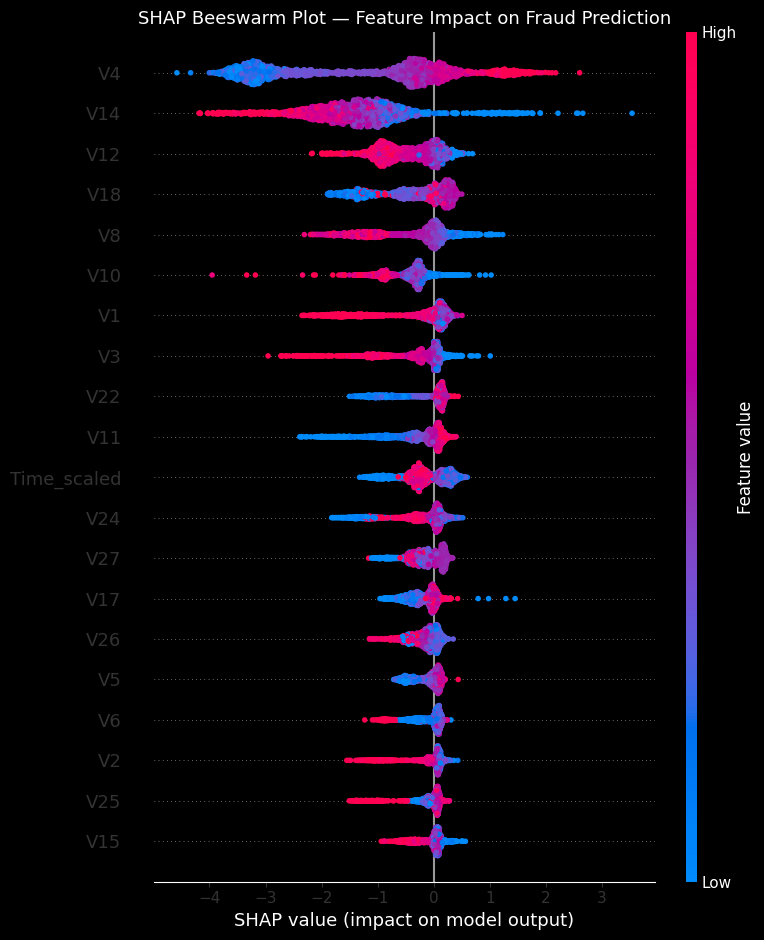


How to read this:
- Each dot = one transaction
- X position = SHAP value (impact on fraud probability)
- Color = feature value (red=high, blue=low)
- V14: when V14 is high (red), SHAP value is negative -> pushes AWAY from fraud


In [8]:
# Beeswarm plot — shows direction and magnitude for each feature
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_sample,
    show=False
)
plt.title('SHAP Beeswarm Plot — Feature Impact on Fraud Prediction', fontsize=13)
plt.tight_layout()
plt.savefig(f'{REPORTS_DIR}/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nHow to read this:')
print('- Each dot = one transaction')
print('- X position = SHAP value (impact on fraud probability)')
print('- Color = feature value (red=high, blue=low)')
print('- V14: when V14 is high (red), SHAP value is negative -> pushes AWAY from fraud')

## 4. Local Explainability — Individual Prediction

In [9]:
# Find a correctly predicted fraud transaction
y_test_sample = y_test[X_sample.index]
y_pred_sample = xgb.predict(X_sample)
y_prob_sample = xgb.predict_proba(X_sample)[:, 1]

# Get a high-confidence fraud
fraud_mask = (y_test_sample == 1) & (y_pred_sample == 1)
fraud_indices = np.where(fraud_mask)[0]

if len(fraud_indices) > 0:
    idx = fraud_indices[np.argmax(y_prob_sample[fraud_mask])]  # Highest confidence
    print(f'Selected transaction index: {idx}')
    print(f'Fraud probability: {y_prob_sample[idx]:.4f}')
    print(f'Actual label: FRAUD')
else:
    idx = 0
    print('No fraud in sample, using index 0')

Selected transaction index: 1109
Fraud probability: 0.9998
Actual label: FRAUD


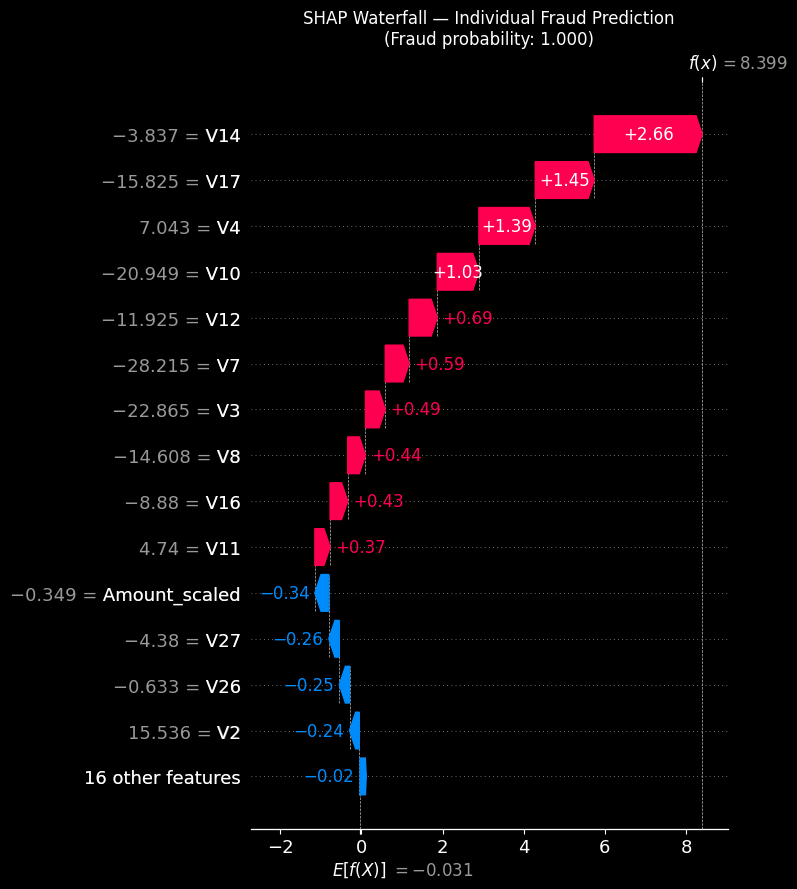


This is what the Streamlit app will show for each prediction!


In [10]:
# Waterfall plot — explains ONE prediction
shap_explanation = shap.Explanation(
    values=shap_values[idx],
    base_values=explainer.expected_value,
    data=X_sample.iloc[idx].values,
    feature_names=feature_cols
)

plt.figure(figsize=(10, 6))
shap.waterfall_plot(shap_explanation, show=False, max_display=15)
plt.title(f'SHAP Waterfall — Individual Fraud Prediction\n(Fraud probability: {y_prob_sample[idx]:.3f})', fontsize=12)
plt.tight_layout()
plt.savefig(f'{REPORTS_DIR}/shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nThis is what the Streamlit app will show for each prediction!')

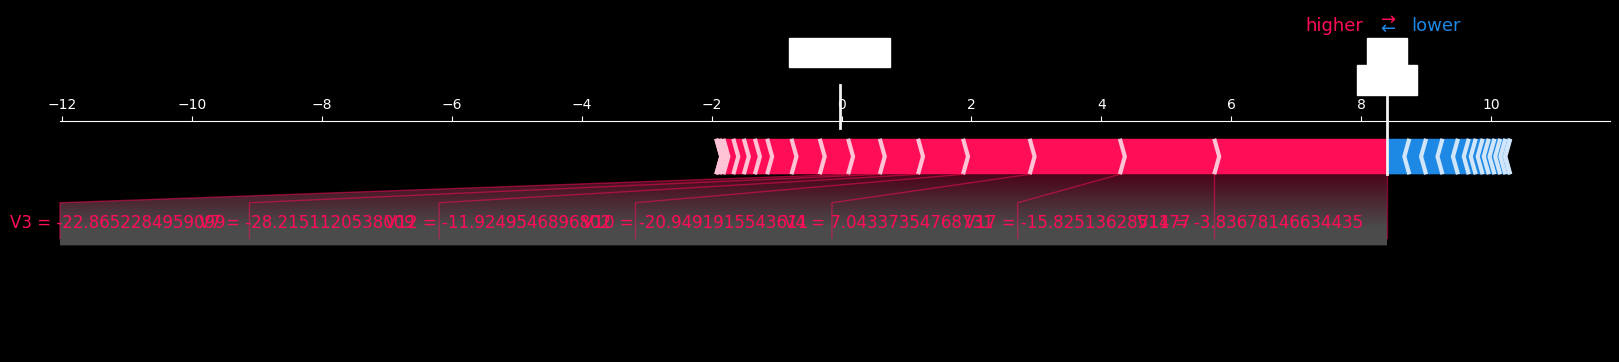

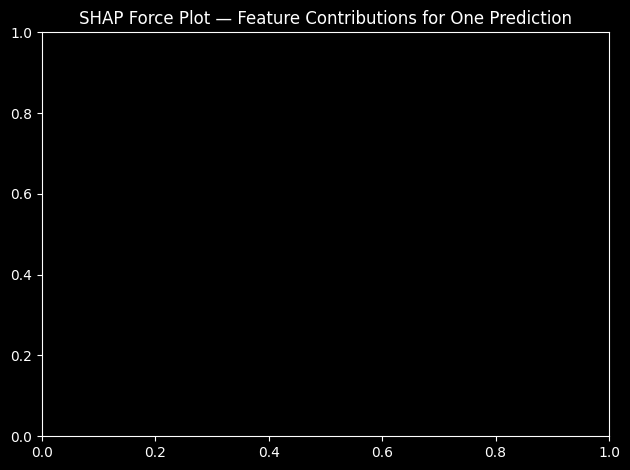

In [11]:
# Force plot
force = shap.force_plot(
    explainer.expected_value,
    shap_values[idx],
    X_sample.iloc[idx],
    feature_names=feature_cols,
    matplotlib=True
)
plt.title('SHAP Force Plot — Feature Contributions for One Prediction')
plt.tight_layout()
plt.savefig(f'{REPORTS_DIR}/shap_force_plot.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. SHAP Dependence Plots — Feature Interactions

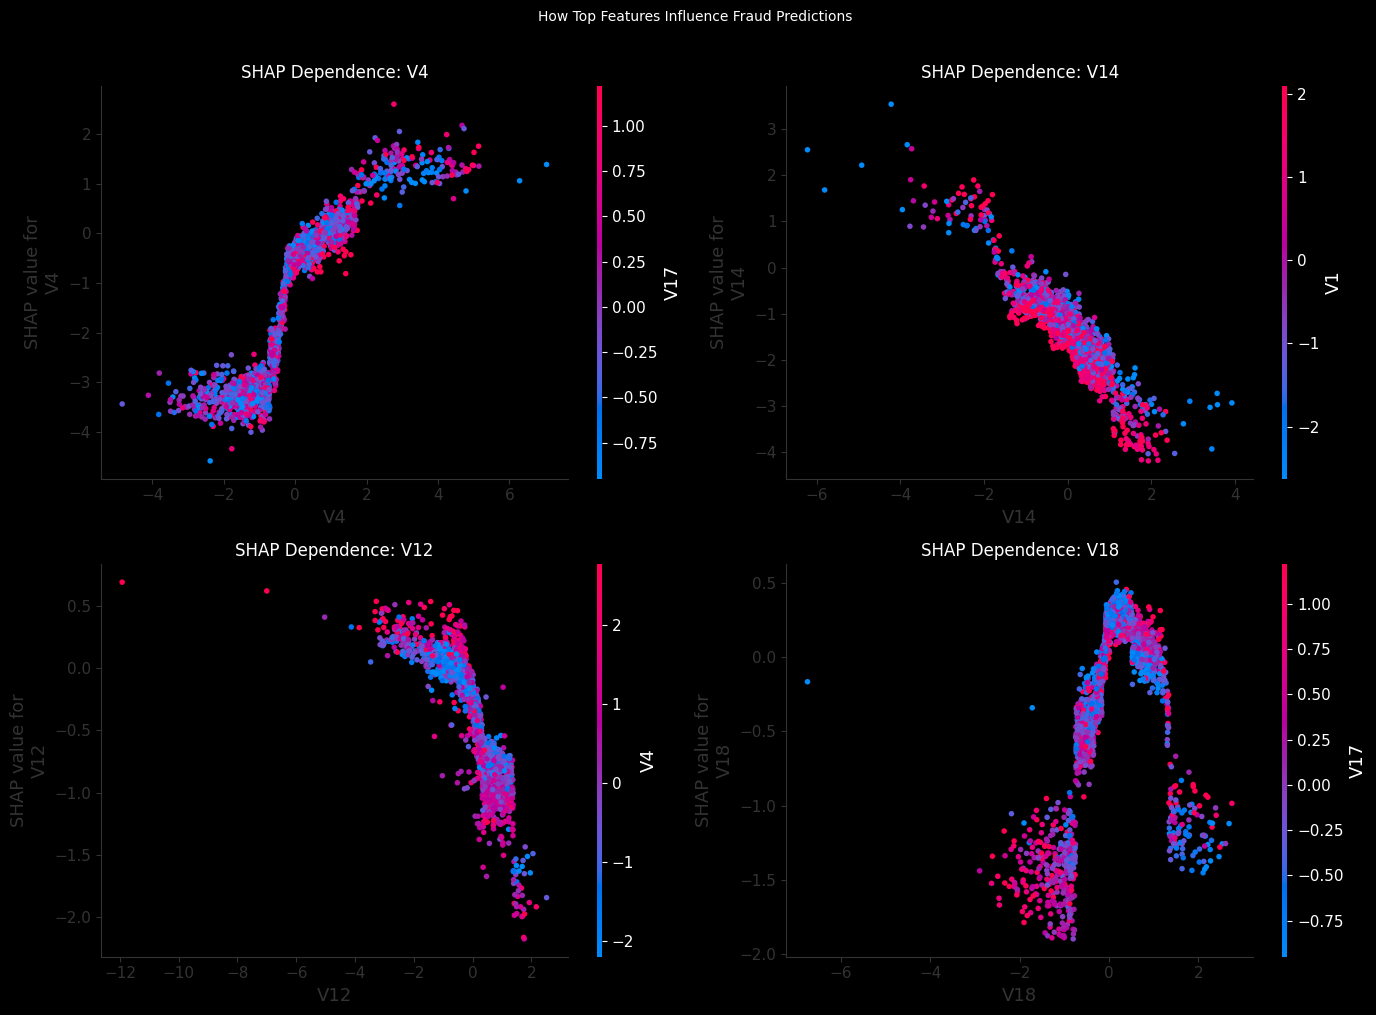

In [15]:
# Top feature dependence plots
top_features = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=feature_cols
).nlargest(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    shap.dependence_plot(
        feat,
        shap_values,
        X_sample,
        ax=axes[i],
        show=False
    )
    axes[i].set_title(f'SHAP Dependence: {feat}')

plt.suptitle('How Top Features Influence Fraud Predictions', fontsize=10, y=1.01)
plt.tight_layout()
plt.savefig(f'{REPORTS_DIR}/shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Top SHAP Features Function (for API use)

In [16]:
def get_top_shap_features(model, explainer, input_df, top_n=5):
    """
    Returns top N features influencing the prediction with their SHAP values.
    """
    sv = explainer.shap_values(input_df)
    feature_names = input_df.columns.tolist()

    shap_df = pd.DataFrame({
        'feature': feature_names,
        'shap_value': sv[0],
        'abs_shap': np.abs(sv[0])
    }).sort_values('abs_shap', ascending=False).head(top_n)

    return {
        'features': shap_df['feature'].tolist(),
        'shap_values': [round(v, 4) for v in shap_df['shap_value'].tolist()],
        'directions': ['towards fraud' if v > 0 else 'towards legitimate'
                       for v in shap_df['shap_value'].tolist()]
    }

# Test it
test_tx = X_sample.iloc[[idx]]
result = get_top_shap_features(xgb, explainer, test_tx)
print('Top 5 features for this prediction:')
for feat, val, direction in zip(result['features'], result['shap_values'], result['directions']):
    print(f'  {feat:20s}: {val:+.4f}  ({direction})')

Top 5 features for this prediction:
  V14                 : +2.6606  (towards fraud)
  V17                 : +1.4530  (towards fraud)
  V4                  : +1.3893  (towards fraud)
  V10                 : +1.0254  (towards fraud)
  V12                 : +0.6931  (towards fraud)


## 7. Summary
| Plot | What it shows | Where used |
|---|---|---|
| Summary bar | Global feature importance | README, report |
| Beeswarm | Direction + spread for all features | README |
| Waterfall | Why one transaction was flagged | Streamlit app |
| Force plot | Same as waterfall, different style | Jupyter demo |
| Dependence | How feature value affects prediction | EDA insight |

**Interview tip:** "I used SHAP TreeExplainer to make the XGBoost model interpretable. For any flagged transaction, the app shows which features drove that decision — for example, V14 below -10 consistently pushed toward fraud. This kind of explainability is critical in fintech where regulators may ask why a transaction was blocked."